In [ ]:
# imports for EDA 
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt



In [3]:
df = pd.read_csv('train.csv')
df

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [13]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
df.isnull().sum()

id                               0
comment_text                     0
toxic                            0
severe_toxic                     0
obscene                          0
threat                           0
insult                           0
identity_hate                    0
comment_has_more_than_1_label    0
dtype: int64

In [6]:
df.iloc[6]

id                                           0002bcb3da6cb337
comment_text     COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK
toxic                                                       1
severe_toxic                                                1
obscene                                                     1
threat                                                      0
insult                                                      1
identity_hate                                               0
Name: 6, dtype: object

=== Label Class Distributions ===
               Total Count  Percentage (%)
toxic                15294            9.58
obscene               8449            5.29
insult                7877            4.94
severe_toxic          1595            1.00
identity_hate         1405            0.88
threat                 478            0.30


C:\Users\mocam\AppData\Local\Temp\ipykernel_30152\627297795.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


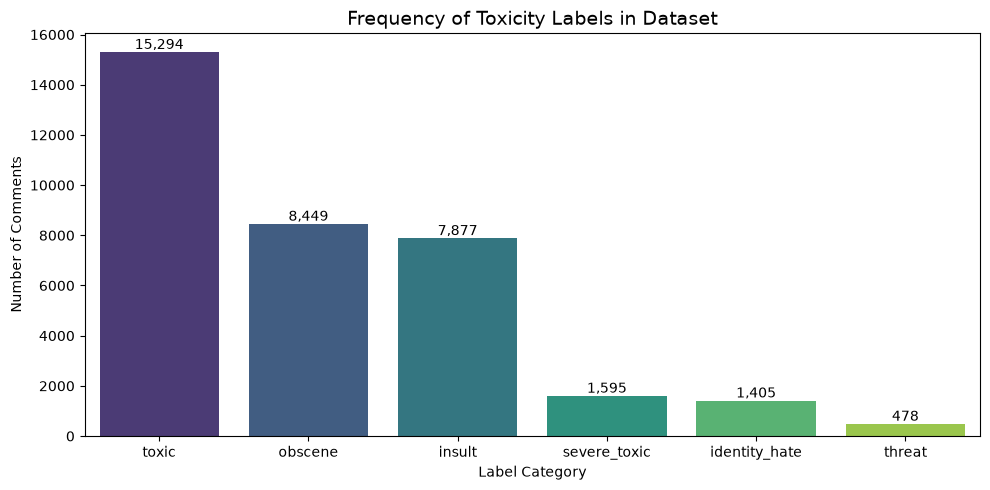

In [15]:
import seaborn as sns

# Target label columns
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

# Calculate raw counts and percentages
label_counts = df[label_cols].sum().sort_values(ascending=False)
label_percents = (label_counts / len(df)) * 100

summary_df = pd.DataFrame({
    'Total Count': label_counts,
    'Percentage (%)': label_percents.round(2)
})
print("=== Label Class Distributions ===")
print(summary_df)

# Plot class distribution
plt.figure(figsize=(10, 5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title("Frequency of Toxicity Labels in Dataset", fontsize=14)
plt.ylabel("Number of Comments")
plt.xlabel("Label Category")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

In [7]:
df['comment_text'].iloc[6]

'COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK'

In [8]:
df['comment_has_more_than_1_label'] = df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum(axis=1) > 1

In [20]:
df['comment_has_all_zero_labels'] = df[['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']].sum(axis=1) == 0
print(df['comment_has_all_zero_labels'].value_counts())
# percentage of comments with all zero labels
percentage_all_zero = df['comment_has_all_zero_labels'].value_counts(normalize=True) * 100
print(f"Percentage of comments with all zero labels: {percentage_all_zero[True]:.2f}%")

comment_has_all_zero_labels
True     143346
False     16225
Name: count, dtype: int64
Percentage of comments with all zero labels: 89.83%


In [12]:
df['comment_has_more_than_1_label'].value_counts()
# calculate the percentage of comments with more than 1 label
percentage = df['comment_has_more_than_1_label'].value_counts(normalize=True) * 100
print(f"Percentage of comments with more than 1 label: {percentage[True]:.2f}%")

Percentage of comments with more than 1 label: 6.18%


=== Distribution of Labels per Comment ===
Clean Comments (0 labels) : 143,346 (89.83%)
Tagged with 1 label(s)    : 6,360 (3.99%)
Tagged with 2 label(s)    : 3,480 (2.18%)
Tagged with 3 label(s)    : 4,209 (2.64%)
Tagged with 4 label(s)    : 1,760 (1.10%)
Tagged with 5 label(s)    : 385 (0.24%)
Tagged with 6 label(s)    : 31 (0.02%)


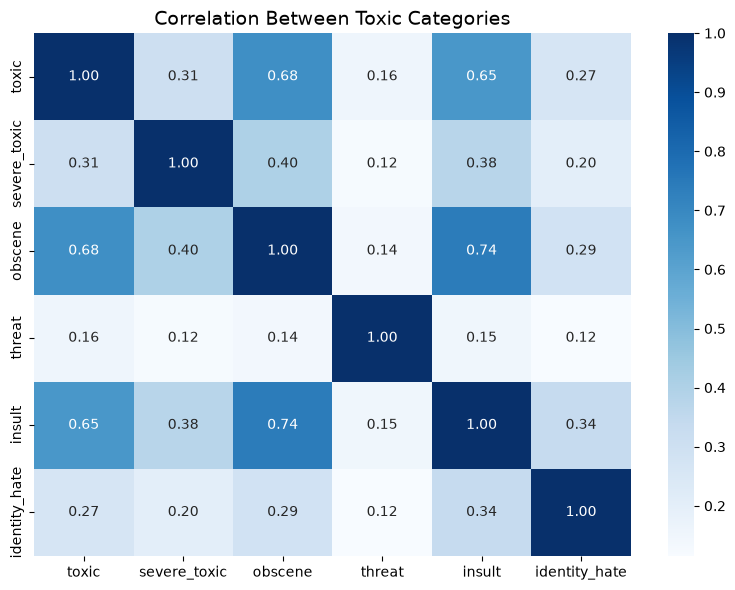

In [21]:
# Count how many labels each row has
df['label_count'] = df[label_cols].sum(axis=1)

# Count distribution of label overlaps
co_occurrence = df['label_count'].value_counts().sort_index()

print("=== Distribution of Labels per Comment ===")
for count, freq in co_occurrence.items():
    pct = (freq / len(df)) * 100
    if count == 0:
        print(f"Clean Comments (0 labels) : {freq:,} ({pct:.2f}%)")
    else:
        print(f"Tagged with {count} label(s)    : {freq:,} ({pct:.2f}%)")

# Plot Label Co-occurrence Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = df[label_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='Blues')
plt.title("Correlation Between Toxic Categories", fontsize=14)
plt.tight_layout()
plt.show()

## Text Sequence Length Analysis

=== Sequence Length Summary (Word Count) ===
count    159571.000000
mean         67.273527
std          99.230702
min           1.000000
50%          36.000000
75%          75.000000
90%         152.000000
95%         230.000000
99%         567.000000
max        1411.000000
Name: word_count, dtype: float64


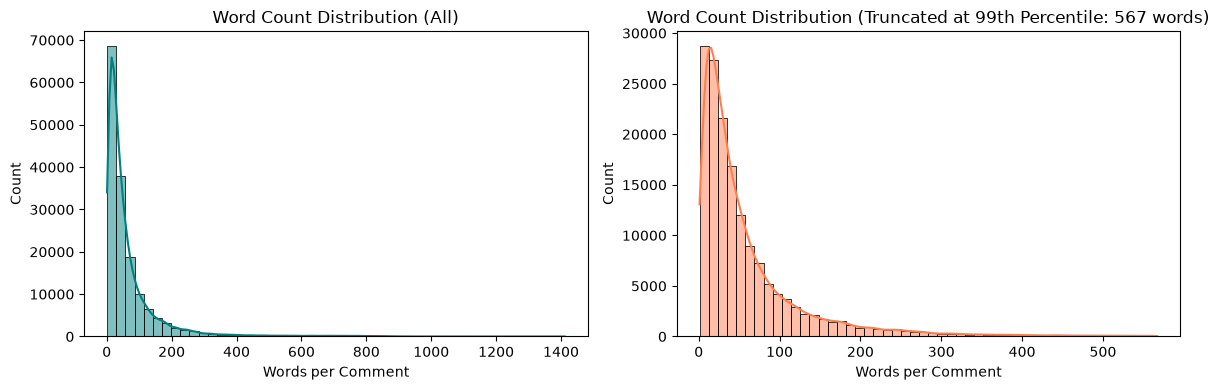

In [22]:
# Compute word and character counts
df['char_len'] = df['comment_text'].astype(str).str.len()
df['word_count'] = df['comment_text'].astype(str).apply(lambda x: len(x.split()))

print("=== Sequence Length Summary (Word Count) ===")
print(df['word_count'].describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]))

# Plot Word Count Distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['word_count'], bins=50, color='teal', kde=True)
plt.title("Word Count Distribution (All)")
plt.xlabel("Words per Comment")

plt.subplot(1, 2, 2)
# Zoomed view below 99th percentile (filters extreme outliers)
p99 = df['word_count'].quantile(0.99)
sns.histplot(df[df['word_count'] <= p99]['word_count'], bins=50, color='coral', kde=True)
plt.title(f"Word Count Distribution (Truncated at 99th Percentile: {int(p99)} words)")
plt.xlabel("Words per Comment")

plt.tight_layout()
plt.show()

## Dublicates check

In [25]:
exact_row_dups = df.duplicated().sum()
print(f"Total exact duplicate rows across all columns: {exact_row_dups}")

Total exact duplicate rows across all columns: 0
